In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Parth\Desktop\VertexPlus\Solar power dataset.csv")

In [3]:
df.head(4)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0


In [4]:
df.isnull().sum()

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [5]:
#No null values
df.describe()

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


Text(0.5, 0, 'DC_POWER')

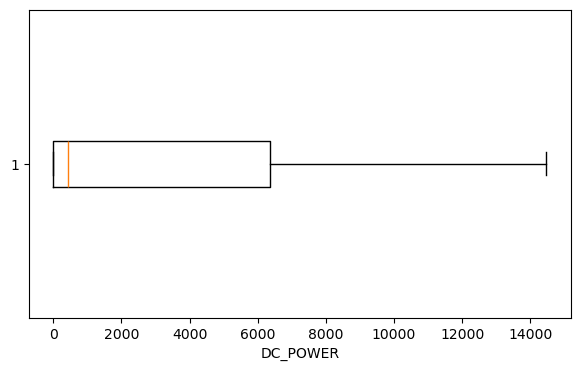

In [6]:
# Since values differ too much in DC_POWER, AC_POWER and DAILY_YIELD we will use standardization
plt.figure(figsize=(7,4))
plt.boxplot(x=df["DC_POWER"],vert=False)
plt.xlabel("DC_POWER")

Text(0.5, 0, 'AC_POWER')

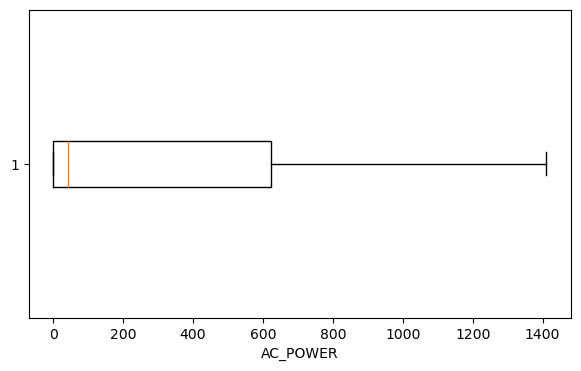

In [7]:
#No outliers in DC_POWER
plt.figure(figsize=(7,4))
plt.boxplot(x=df["AC_POWER"],vert=False)
plt.xlabel("AC_POWER")

Text(0.5, 0, 'DAILY_YIELD')

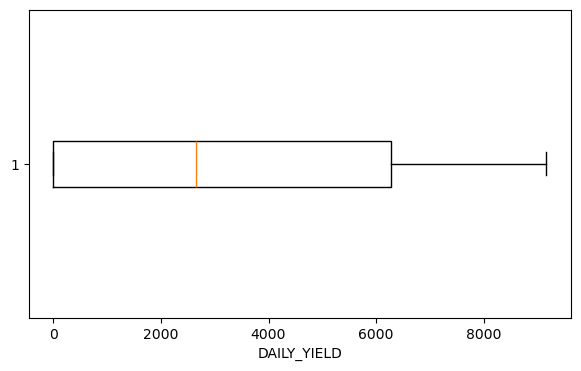

In [8]:
#No outliers in AC_POWER also
plt.figure(figsize=(7,4))
plt.boxplot(x=df["DAILY_YIELD"],vert=False)
plt.xlabel("DAILY_YIELD")

In [9]:
df.drop(columns=["PLANT_ID","SOURCE_KEY"],inplace=True)
df

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,0.0,0.0,0.000,6259559.0
1,15-05-2020 00:00,0.0,0.0,0.000,6183645.0
2,15-05-2020 00:00,0.0,0.0,0.000,6987759.0
3,15-05-2020 00:00,0.0,0.0,0.000,7602960.0
4,15-05-2020 00:00,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...
68773,17-06-2020 23:45,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,0.0,0.0,5817.000,6583369.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   DC_POWER     68778 non-null  float64
 2   AC_POWER     68778 non-null  float64
 3   DAILY_YIELD  68778 non-null  float64
 4   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), object(1)
memory usage: 2.6+ MB


In [11]:
from datetime import datetime


def try_parsing_date(x):
    # If it's already a Timestamp or datetime, just return it
    if isinstance(x, (pd.Timestamp, datetime)):
        return x
    
    # Otherwise, try parsing as string
    tp = ('%d-%m-%Y %H:%M', '%m/%d/%Y %H:%M')
    try:
        return datetime.strptime(str(x), tp[0])
    except Exception as e:
        return datetime.strptime(str(x), tp[1])

df['DATE_TIME'] = df['DATE_TIME'].apply(try_parsing_date)


In [12]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   DC_POWER     68778 non-null  float64       
 2   AC_POWER     68778 non-null  float64       
 3   DAILY_YIELD  68778 non-null  float64       
 4   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 2.6 MB


DATE_TIME      0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [13]:
df.set_index('DATE_TIME')

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
DATE_TIME,,,,
2020-05-15 00:00:00,0.0,0.0,0.000,6259559.0
2020-05-15 00:00:00,0.0,0.0,0.000,6183645.0
2020-05-15 00:00:00,0.0,0.0,0.000,6987759.0
2020-05-15 00:00:00,0.0,0.0,0.000,7602960.0
2020-05-15 00:00:00,0.0,0.0,0.000,7158964.0
...,...,...,...,...
2020-06-17 23:45:00,0.0,0.0,5967.000,7287002.0
2020-06-17 23:45:00,0.0,0.0,5147.625,7028601.0
2020-06-17 23:45:00,0.0,0.0,5819.000,7251204.0


Text(0.5, 0, 'DATE_TIME')

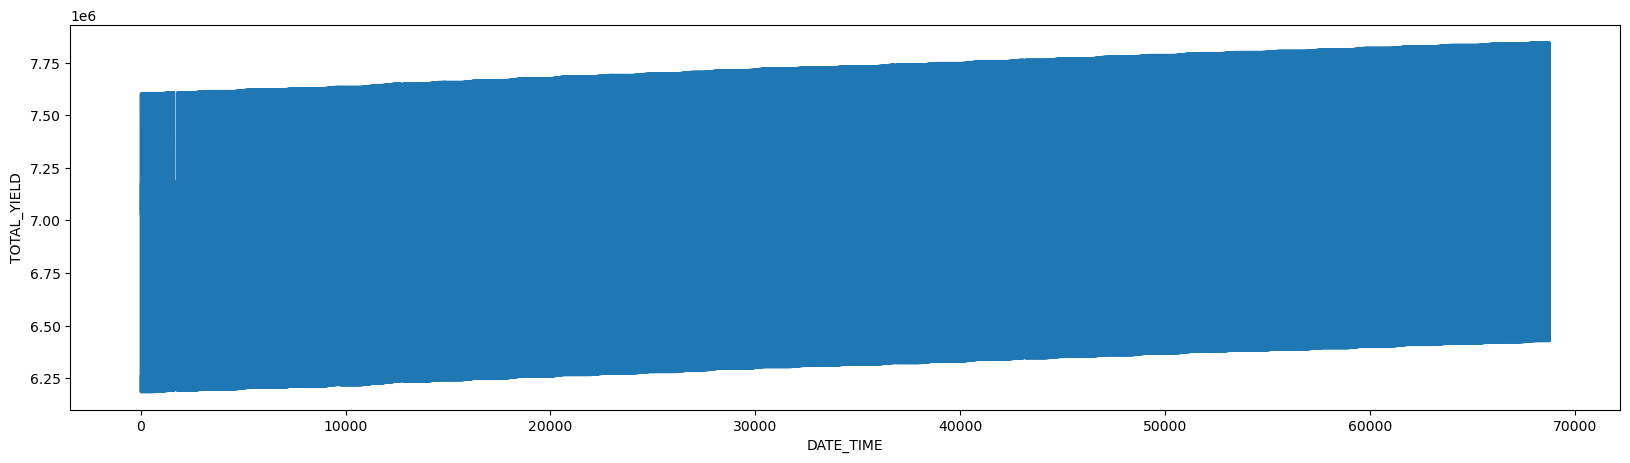

In [14]:
plt.figure(figsize=(20,5))
sns.lineplot(data=df, x=df.index, y='TOTAL_YIELD')
plt.xlabel("DATE_TIME") 



Text(0.5, 0, 'DATE TIME')

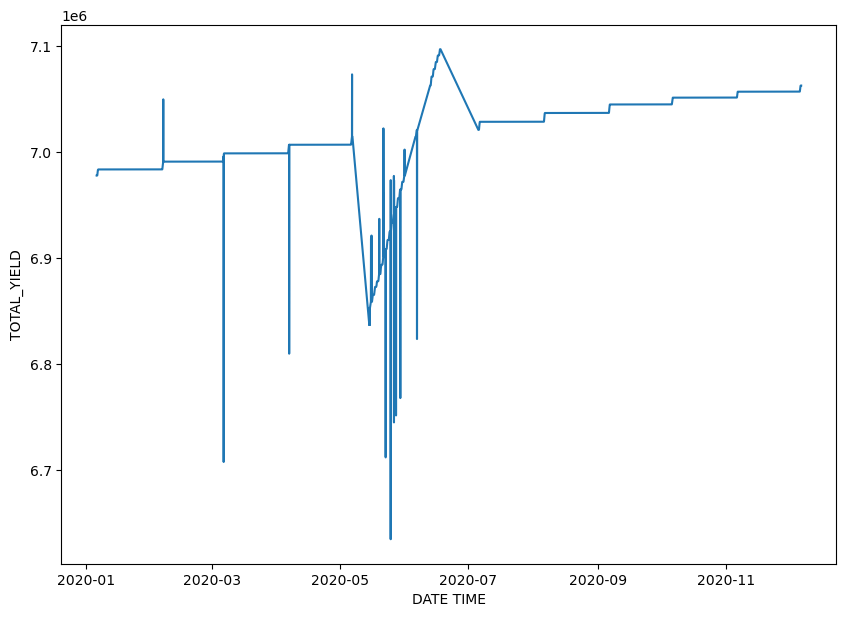

In [15]:
# It is coming area like because we have multiple values at the same time stamp. So now we group the same time stamp by taking mean
df_grouped = df.groupby('DATE_TIME', as_index=False)['TOTAL_YIELD'].mean()
df_grouped.set_index('DATE_TIME',inplace=True)
plt.figure(figsize=(10,7))
sns.lineplot(data=df_grouped, x=df_grouped.index, y='TOTAL_YIELD')
plt.xlabel('DATE TIME')

In [16]:
#Now checking the rolling mean
df_grouped

,TOTAL_YIELD
DATE_TIME,
2020-01-06 00:00:00,6.978158e+06
2020-01-06 00:15:00,6.978158e+06
2020-01-06 00:30:00,6.978158e+06
2020-01-06 00:45:00,6.978158e+06
2020-01-06 01:00:00,6.978158e+06
...,...
2020-12-06 22:45:00,7.063126e+06
2020-12-06 23:00:00,7.063126e+06
2020-12-06 23:15:00,7.063126e+06


In [17]:
df_grouped['rollMean']=df_grouped.TOTAL_YIELD.rolling(window=4).mean()
df_grouped['rollStd']=df_grouped.TOTAL_YIELD.rolling(window=4).std()
print(df_grouped)

                      TOTAL_YIELD      rollMean  rollStd
DATE_TIME                                               
2020-01-06 00:00:00  6.978158e+06           NaN      NaN
2020-01-06 00:15:00  6.978158e+06           NaN      NaN
2020-01-06 00:30:00  6.978158e+06           NaN      NaN
2020-01-06 00:45:00  6.978158e+06  6.978158e+06      0.0
2020-01-06 01:00:00  6.978158e+06  6.978158e+06      0.0
...                           ...           ...      ...
2020-12-06 22:45:00  7.063126e+06  7.063126e+06      0.0
2020-12-06 23:00:00  7.063126e+06  7.063126e+06      0.0
2020-12-06 23:15:00  7.063126e+06  7.063126e+06      0.0
2020-12-06 23:30:00  7.063126e+06  7.063126e+06      0.0
2020-12-06 23:45:00  7.063126e+06  7.063126e+06      0.0

[3158 rows x 3 columns]


<Axes: xlabel='DATE_TIME', ylabel='TOTAL_YIELD'>

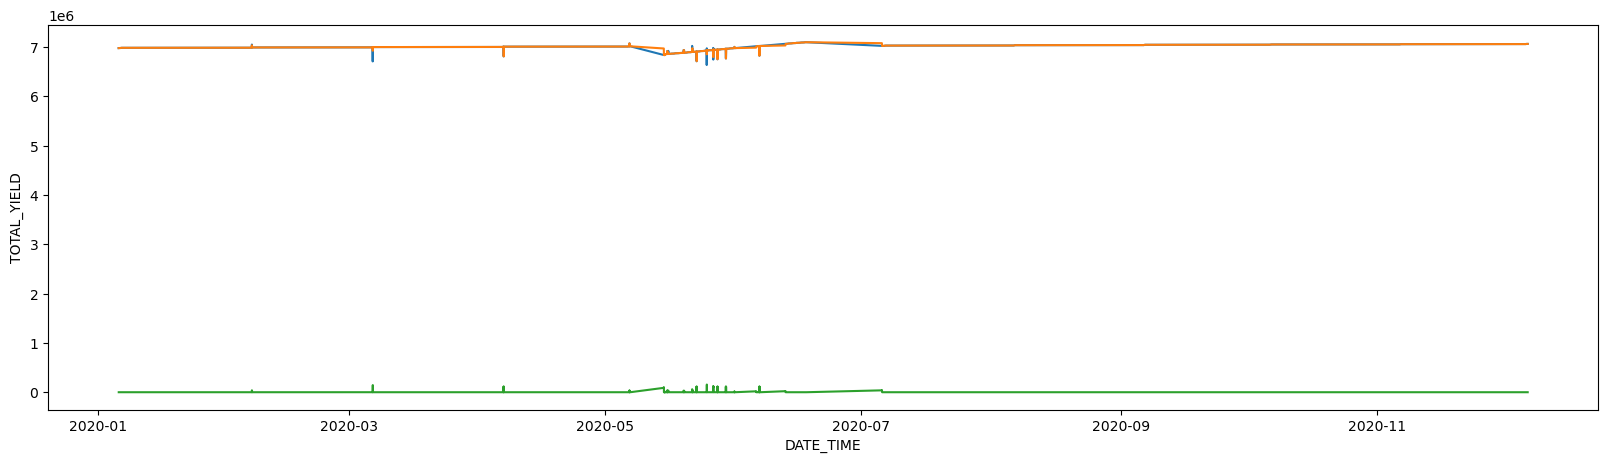

In [18]:
plt.figure(figsize=(20,5))
sns.lineplot(data=df_grouped, x=df_grouped.index, y='TOTAL_YIELD')
sns.lineplot(data=df_grouped,x=df_grouped.index,y=df_grouped.rollMean)
sns.lineplot(data=df_grouped,x=df_grouped.index,y=df_grouped.rollStd)

In [19]:
# Now we have to make the data stationary
# First we are defining a function to test the stationarity of the dataframe
def test_stationarity(dataFrame,var):
    dataFrame['rollMean']=dataFrame[var].rolling(window=4).mean()
    dataFrame['rollStd']=dataFrame[var].rolling(window=4).std()
    sns.lineplot(data=dataFrame,x=dataFrame.index,y=var)
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='rollMean')
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='rollStd')


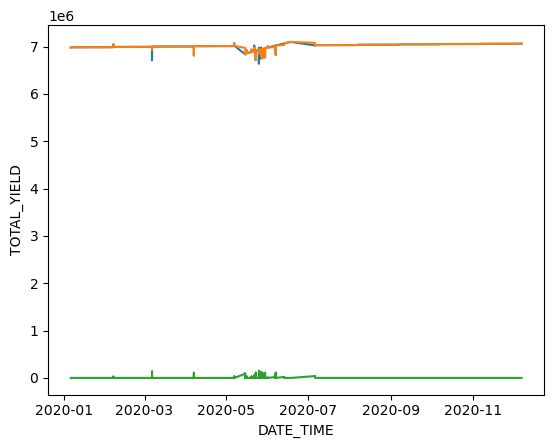

In [20]:
test_stationarity(df_grouped,'TOTAL_YIELD')

In [21]:
# Now trying to make the data stationary
air_df=df_grouped[['TOTAL_YIELD']]
air_df.head()

,TOTAL_YIELD
DATE_TIME,
2020-01-06 00:00:00,6.978158e+06
2020-01-06 00:15:00,6.978158e+06
2020-01-06 00:30:00,6.978158e+06
2020-01-06 00:45:00,6.978158e+06
2020-01-06 01:00:00,6.978158e+06


In [22]:
#time shift
air_df['shift']=air_df.TOTAL_YIELD.shift()
air_df['shiftDiff']=air_df.TOTAL_YIELD-air_df['shift']
air_df.head()

C:\Users\Parth\AppData\Local\Temp\ipykernel_13036\759443845.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_df['shift']=air_df.TOTAL_YIELD.shift()


,TOTAL_YIELD,shift,shiftDiff
DATE_TIME,,,
2020-01-06 00:00:00,6.978158e+06,NaN,NaN
2020-01-06 00:15:00,6.978158e+06,6.978158e+06,0.0
2020-01-06 00:30:00,6.978158e+06,6.978158e+06,0.0
2020-01-06 00:45:00,6.978158e+06,6.978158e+06,0.0
2020-01-06 01:00:00,6.978158e+06,6.978158e+06,0.0


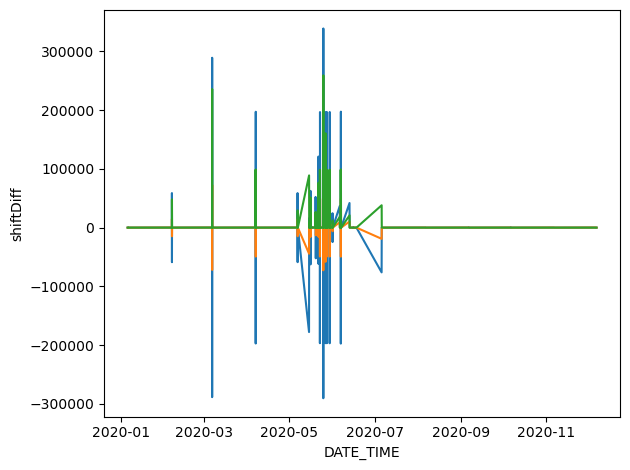

In [23]:
test_stationarity(air_df,'shiftDiff')
plt.tight_layout()


# checking stationarity using ADFULLER AND KPSS TEST

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(air_df['shiftDiff'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
from statsmodels.tsa.stattools import kpss

result = kpss(air_df['shiftDiff'].dropna(), regression='c')
print(f'KPSS Statistic: {result[0]}')
print(f'p-value: {result[1]}')


DATA IS STATIONARY

TRYING SOME MORE COMBINATIONS TO MAKE IT STATIONARY

In [ ]:
log_df = df_grouped[["TOTAL_YIELD"]]
log_df['log']=np.log(df_grouped['TOTAL_YIELD'])
log_df.head()

In [ ]:
test_stationarity(log_df,'log')

In [ ]:
sqrt_df=df_grouped[['TOTAL_YIELD']]
sqrt_df['sqrt']=np.sqrt(df_grouped['TOTAL_YIELD'])
sqrt_df.head()

In [ ]:
test_stationarity(sqrt_df,'sqrt')

In [ ]:
cbrt_df=df_grouped[["TOTAL_YIELD"]]
cbrt_df['cbrt']=np.cbrt(cbrt_df['TOTAL_YIELD'])
cbrt_df.head()

In [ ]:
test_stationarity(cbrt_df,'cbrt')

In [ ]:
log_df2=log_df[["TOTAL_YIELD","log"]]
log_df2['log_sqrt']=np.sqrt(log_df['log'])
log_df2.head()

In [ ]:
test_stationarity(log_df2,'log_sqrt')

In [ ]:
log_df2['logShiftDiff']=log_df2['log_sqrt']-log_df2['log_sqrt'].shift()
log_df2.head()

In [ ]:
test_stationarity(log_df2.dropna(),'logShiftDiff')

In [ ]:
%pip install statsmodels

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(log_df2['logShiftDiff'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

In [ ]:
from statsmodels.tsa.stattools import kpss

result = kpss(log_df2['logShiftDiff'].dropna(), regression='c')
print(f'KPSS Statistic: {result[0]}')
print(f'p-value: {result[1]}')


NOW WE PROCEEDING WITH ARIMA MODEL WITH THE ORIGINAL DATA FRAME BY TAKING THE DIFFERENCE

In [ ]:
# now the data series is stationary. We will proceed with ARIMA 
airP=df_grouped[["TOTAL_YIELD"]]
airP.head()


In [ ]:
airP['firstDiff']=airP['TOTAL_YIELD'].diff(1)

In [ ]:
airP.head()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA


ARIMA HAS PARAMETERS AS P,D,Q
p=auto regressive
d=integrated
q=moving average

now finding p,d,q

In [ ]:
#d=1 since the shift is of one step
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
plot_pacf(airP['firstDiff'].dropna(),lags=10)
plt.show()

Hence the value of P=1 because we will consider the line which will cross the shaded region

In [ ]:
plot_acf(airP['firstDiff'].dropna(),lags=20)
plt.show()

hence q is also 1

In [ ]:
len(airP)

In [ ]:
train = airP[:round(len(airP)*70/100)]
test=airP[round(len(airP)*70/100):]
airP.head()

In [ ]:
test.head()

In [ ]:
# 1. Ensure datetime index
airP.index = pd.to_datetime(airP.index)

# 2. Sort it if needed
airP = airP.sort_index()

# 3. Assign frequency
airP = airP.asfreq('15min')  # Use '15min', not '15T' (deprecated)


In [ ]:
print(train.index)
print(train.index.freq)


In [ ]:
train = train.asfreq('15min')  # '15T' means 15 minutes


In [ ]:
model=ARIMA(train['TOTAL_YIELD'],order=(1,1,1))
model_fit=model.fit()
prediction=model_fit.predict(start=airP.index[0],end=airP.index[-1])
airP['arimaPred']=prediction
airP.head()

In [ ]:
plt.figure(figsize=(20,7))
sns.lineplot(data=airP[1000:],x=airP.index,y='TOTAL_YIELD')
sns.lineplot(data=airP[1000:],x=airP.index,y='arimaPred')


In [ ]:
#TRYING SARIMAX 


In [ ]:
df

In [ ]:
df_grouped

In [ ]:
grouped=df.groupby("DATE_TIME").mean()

In [ ]:
grouped

In [ ]:
grouped.info()

In [ ]:
grouped

In [ ]:
print(grouped.index.dtype)

In [ ]:
y = grouped['TOTAL_YIELD']

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

In [ ]:
# Hence we need to make it stationary

In [ ]:
exog = grouped[['AC_POWER', 'DC_POWER']]

# Differencing to make it stationary
y_diff = y.diff().dropna()
y_diff

Define SARIMAX Grid Search Function
This will search over a range of parameters and select the model with the lowest AIC (best tradeoff between model fit and complexity).

In [ ]:
exog=grouped[['AC_POWER', 'DC_POWER','DAILY_YIELD']]


In [ ]:
# finding the value of dif
y_diff = y.diff().dropna()
from statsmodels.tsa.stattools import adfuller

result = adfuller(y_diff)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

In [ ]:
y_diff

d=1

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# First difference if your series is non-stationary

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(y_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF Plot')
plot_pacf(y_diff, lags=40, ax=axes[1])
axes[1].set_title('PACF Plot')
plt.show()


p=1,q=1

In [ ]:
# grouped=grouped.asfre('15T')
train_size = int(len(grouped) * 0.8)
train_y = y.iloc[:train_size]
test_y = y.iloc[train_size:]

# If you have exogenous variables
train_exog = exog.iloc[:train_size]
test_exog = exog.iloc[train_size:]


from statsmodels.tsa.statespace.sarimax import SARIMAX

order = (1, 1, 1)
seasonal_order = (1, 1, 1, 96)  # for daily seasonality (96 x 15min = 24 hours)

model = SARIMAX(train_y, exog=train_exog, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)

results = model.fit(method='lbfgs', disp=True, maxiter=50)


In [ ]:
# Number of steps to forecast
n_forecast = len(test_y)

# Forecast using the test exogenous variables
forecast = results.get_forecast(steps=n_forecast, exog=test_exog)
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_y, predicted_mean)
rmse = np.sqrt(mean_squared_error(test_y, predicted_mean))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(test_y.index, test_y, label='Actual')
plt.plot(test_y.index, predicted_mean, label='Forecast', color='red')
# plt.fill_between(test_y.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title("SARIMAX Forecast vs Actual")
plt.show()


# PLOTTING ON THE WHOLE DATA

In [ ]:
# Number of steps to forecast
n_forecast = len(y)

# Forecast using the test exogenous variables
forecast = results.get_forecast(steps=n_forecast, exog=exog)
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, predicted_mean)
rmse = np.sqrt(mean_squared_error(y, predicted_mean))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y.index[1000:50000], y[1000:50000], label='Actual')
plt.plot(y.index[1000:50000], predicted_mean[1000:50000], label='Forecast', color='red')
plt.legend()
plt.title("SARIMAX Forecast vs Actual")
plt.show()